## Предсказание поломки оборудования
Цель: Нужно предсказать, произойдёт ли отказ оборудования на основе его технических характеристик, условий эксплуатации и истории работы.

Расшифровка столбцов датасета

Идентификаторы:
- id - Уникальный числовой идентификатор записи
- Product ID - Идентификатор продукта/оборудования (формат: буква + цифры)
- Type - Тип оборудования (категория: L, M, H - Low/Medium/High)
- 
Технологические параметры:
- Air temperature [K] - Температура окружающего воздуха в Кельвинах
- Process temperature [K] - Технологическая температура процесса в Кельвинах
- Rotational speed [rpm] - Скорость вращения в оборотах в минуту
- Torque [Nm] - Крутящий момент в Ньютон-метрах
- Tool wear [min] - Износ инструмента в минутах работы

Признаки отказов:
- Machine failure - Общий индикатор отказа оборудования (1 - отказ, 0 - норма)
- TWF - Tool Wear Failure (Отказ из-за износа инструмента)
- HDF - Heat Dissipation Failure (Отказ теплоотвода)
- PWF - Power Failure (Отказ питания)
- OSF - Overstrain Failure (Отказ из-за перегрузки)
- RNF - Random Failures (Случайные отказы)

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from phik import resources, report
import plotly.io as pio
pio.renderers.default = "iframe"
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# библиотеки логистической регрессии
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

# библиотеки для пайплайна
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, f1_score, fbeta_score
from sklearn.dummy import DummyClassifier

!pip install imbalanced-learn -q 


from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
#from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.metrics import ConfusionMatrixDisplay
#np.seterr(invalid='ignore')

#from lightgbm import LGBMRegressor
from xgboost import XGBClassifier

from sklearn.impute import KNNImputer
from catboost import Pool, CatBoostRegressor, cv
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import validation_curve
from sklearn.model_selection import StratifiedKFold
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
from sklearn.tree import plot_tree
from sklearn.metrics import matthews_corrcoef
from sklearn.base import BaseEstimator, TransformerMixin
import traceback
import joblib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%config IPCompleter.greedy=True

## Загрузка датасета

In [6]:
def inspect_df(a):
    a.info()
    display(a.head())

In [7]:
train = pd.read_csv('/datasets/ai4i2020.csv')

In [8]:
inspect_df(train)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Исследовательский анализ данных

In [10]:
train.select_dtypes(include='object').describe()

,Product ID,Type
count,10000,10000
unique,10000,3
top,L57163,L
freq,1,6000


In [11]:
def desboxshaptrain(a, b):
    # Выводим имя столбца
    display(b)
    
    # Статистика по столбцу
    display(a[b].describe())
    display(px.box(a, y=b, width=400, height=400, title=b))
    display(px.histogram(a, x=b, marginal='box'))

In [12]:
numer0 = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
for i in numer0:
    desboxshaptrain(train, i)

'Air temperature [K]'

count    10000.000000
mean       300.004930
std          2.000259
min        295.300000
25%        298.300000
50%        300.100000
75%        301.500000
max        304.500000
Name: Air temperature [K], dtype: float64

'Process temperature [K]'

count    10000.000000
mean       310.005560
std          1.483734
min        305.700000
25%        308.800000
50%        310.100000
75%        311.100000
max        313.800000
Name: Process temperature [K], dtype: float64

'Rotational speed [rpm]'

count    10000.000000
mean      1538.776100
std        179.284096
min       1168.000000
25%       1423.000000
50%       1503.000000
75%       1612.000000
max       2886.000000
Name: Rotational speed [rpm], dtype: float64

'Torque [Nm]'

count    10000.000000
mean        39.986910
std          9.968934
min          3.800000
25%         33.200000
50%         40.100000
75%         46.800000
max         76.600000
Name: Torque [Nm], dtype: float64

'Tool wear [min]'

count    10000.000000
mean       107.951000
std         63.654147
min          0.000000
25%         53.000000
50%        108.000000
75%        162.000000
max        253.000000
Name: Tool wear [min], dtype: float64

## Оценка численных признаков через целевой признак

In [14]:
display(px.box(train, y='Air temperature [K]', color='Machine failure', width=400, height=400, title='Air temperature [K]'))

In [15]:
display(px.box(train, y='Process temperature [K]', color='Machine failure', width=400, height=400, title='Process temperature [K]'))

In [16]:
display(px.box(train, y='Rotational speed [rpm]', color='Machine failure', width=400, height=400, title='Rotational speed [rpm]'))

In [17]:
display(px.box(train, y='Torque [Nm]', color='Machine failure', width=400, height=400, title='Torque [Nm]'))

In [18]:
display(px.box(train, y='Tool wear [min]', color='Machine failure', width=400, height=400, title='Tool wear [min]'))

## Оценка категориальных признаков через таргет

In [20]:
display(train['Machine failure'].value_counts())
display(train['Machine failure'].value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [21]:
def valuepietrain(a, b):
    display(b)
    display(a[b].value_counts())
    display(a[b].value_counts(normalize=True))
    display(px.pie(a, names=b, title=b))
    display(px.density_heatmap(a, x='Machine failure', y=b,
                         color_continuous_scale='Viridis',
                         title=b))

In [22]:
cat0 = ['Product ID', 'Type']
for i in cat0:
    valuepietrain(train, i)

'Product ID'

Product ID
L57163    1
M24842    1
L57161    1
L57160    1
L57159    1
         ..
L47184    1
L47183    1
L47182    1
L47181    1
M14860    1
Name: count, Length: 10000, dtype: int64

Product ID
L57163    0.0001
M24842    0.0001
L57161    0.0001
L57160    0.0001
L57159    0.0001
           ...  
L47184    0.0001
L47183    0.0001
L47182    0.0001
L47181    0.0001
M14860    0.0001
Name: proportion, Length: 10000, dtype: float64

'Type'

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type
L    0.6000
M    0.2997
H    0.1003
Name: proportion, dtype: float64

In [23]:
colors_blue = ["#132C33", "#264D58", '#17869E', '#51C4D3', '#B4DBE9']
colors_dark = ["#1F1F1F", "#313131", '#636363', '#AEAEAE', '#DADADA']
colors_green = ['#01411C','#4B6F44','#4F7942','#74C365','#D0F0C0']
color_red = '#d62728'

In [24]:
fig = px.scatter_matrix(train, train.drop('Machine failure', axis=1),height=1250,width=1100,template='plotly_white',opacity=0.7,
                       color_discrete_sequence=[color_red, colors_blue[3]],color='Machine failure',
                       symbol='Machine failure',color_continuous_scale=[color_red, colors_blue[3]])
fig.update_layout(font_family='monospace',font_size=10,
                  coloraxis_showscale=False,
                 legend=dict(x=0.02,y=1.07,bgcolor=colors_dark[4]),
                 title=dict(text='Точечный график признаков',x=0.5,y=0.97,
                   font=dict(color=colors_dark[2],size=24)))
fig.show()

### Оценка численных признаков через TWF - Tool Wear Failure (Отказ из-за износа инструмента)

In [26]:
display(px.box(train, y='Air temperature [K]', color='TWF', width=400, height=400, title='Air temperature [K]'))

In [27]:
display(px.box(train, y='Process temperature [K]', color='TWF', width=400, height=400, title='Process temperature [K]'))

In [28]:
display(px.box(train, y='Rotational speed [rpm]', color='TWF', width=400, height=400, title='Rotational speed [rpm]'))

In [29]:
display(px.box(train, y='Torque [Nm]', color='TWF', width=400, height=400, title='Torque [Nm]'))

In [30]:
display(px.box(train, y='Tool wear [min]', color='TWF', width=400, height=400, title='Tool wear [min]'))

Наблюдается зависимость признаков Tool wear [min] и TWF - 0: Q25-Q75: 53-162, 1: Q25-Q75: 198-26

### Оценка численных признаков через HDF - Heat Dissipation Failure (Отказ теплоотвода)

In [33]:
display(px.box(train, y='Air temperature [K]', color='HDF', width=400, height=400, title='Air temperature [K]'))

Наблюдается зависимость признака Air temperature [K] от HDF - 0: Q25-Q75: 298.3-301.5, 1: Q25-Q75: 302.1-303.075

In [35]:
display(px.box(train, y='Process temperature [K]', color='HDF', width=400, height=400, title='Process temperature [K]'))

In [36]:
display(px.box(train, y='Rotational speed [rpm]', color='HDF', width=400, height=400, title='Rotational speed [rpm]'))

Наблюдается зависимость признака - Rotational speed [rpm] от HDF - 0: Q25-Q75: 1426-1614, 1: Q25-Q75: 1259-1379

In [38]:
display(px.box(train, y='Torque [Nm]', color='HDF', width=400, height=400, title='Torque [Nm]'))

Наблюдается зависимость признака Torque [Nm] от HDF - 0: Q25-Q75: 33.1-46.6, 1: Q25-Q75: 48.2-57.1

In [40]:
display(px.box(train, y='Tool wear [min]', color='HDF', width=400, height=400, title='Tool wear [min]'))

Создадим новый признак: 'HDF_temp' - разница признаков 'Process temperature [K]' и 'Air temperature [K]':

In [42]:
train['HDF_temp'] = train['Process temperature [K]'] - train['Air temperature [K]']

In [43]:
display(px.box(train, y='HDF_temp', color='HDF', width=400, height=400, title='HDF_temp'))

Наблюдается зависимость признака HDF_temp от HDF: Q25-Q75: 9.3-11, 1: Q25-Q75: 7.6-8.6

### Оценка численных признаков через PWF - Power Failure (Отказ питания)

In [46]:
display(px.box(train, y='Air temperature [K]', color='PWF', width=400, height=400, title='Air temperature [K]'))

In [47]:
display(px.box(train, y='Process temperature [K]', color='PWF', width=400, height=400, title='Process temperature [K]'))

In [48]:
display(px.box(train, y='Rotational speed [rpm]', color='PWF', width=400, height=400, title='Rotational speed [rpm]'))

Наблюдается зависимость признака Rotational speed [rpm] от PWF-  0: Q25-Q75: 1424-1611, 1: Q25-Q75: 1312-2563.75

In [50]:
display(px.box(train, y='Torque [Nm]', color='PWF', width=400, height=400, title='Torque [Nm]'))

Наблюдается зависимость признака Torque [Nm] от PWF - 0: Q25-Q75: 33.2-46.6, 1: Q25-Q75: 12.8-68.45

In [52]:
display(px.box(train, y='Tool wear [min]', color='PWF', width=400, height=400, title='Tool wear [min]'))

Создадим новый признак: 'PWF_n' - произведение признаков 'Torque [Nm]' и 'Rotational speed [rpm]'.

In [54]:
train['PWF_n'] = train['Torque [Nm]'] * train['Rotational speed [rpm]'] / 60

In [55]:
display(px.box(train, y='PWF_n', color='PWF', width=400, height=400, title='PWF_n'))

Наблюдается зависимость признака PWF_n от PWF - 0: Q25-Q75: 885.6-1112.2, 1: Q25-Q75: 546.8-1494

### Оценка численных признаков через OSF - Overstrain Failure (Отказ из-за перегрузки)

In [58]:
display(px.box(train, y='Air temperature [K]', color='OSF', width=400, height=400, title='Air temperature [K]'))

In [59]:
display(px.box(train, y='Process temperature [K]', color='OSF', width=400, height=400, title='Process temperature [K]'))

In [60]:
display(px.box(train, y='Rotational speed [rpm]', color='OSF', width=400, height=400, title='Rotational speed [rpm]'))

In [61]:
display(px.box(train, y='Torque [Nm]', color='OSF', width=400, height=400, title='Torque [Nm]'))

Наблюдается зависимость признака Torque [Nm] от OSF  - 0: Q25-Q75: 33.1-46.6, 1: Q25-Q75: 46.3-70.5

In [63]:
display(px.box(train, y='Tool wear [min]', color='OSF', width=400, height=400, title='Tool wear [min]'))

Наблюдается зависимость признака Tool wear [min] от OSF - 0: Q25-Q75: 52-161, 1: Q25-Q75: 172-238

Создадим признак 'OSF_n' - произведение признаков 'Torque [Nm]' и 'Tool wear [min]'.

In [66]:
train['OSF_n'] = train['Torque [Nm]'] * train['Tool wear [min]']

In [67]:
display(px.box(train, y='OSF_n', color='OSF', width=400, height=400, title='OSF_n'))

Наблюдается зависимость признака OSF_n от OSF - 0: Q25-Q75: 1846.87-6232.8, 1: Q25-Q75: 110032.8-16479

In [69]:
display(px.box(train, x='Type', y='OSF_n', color='OSF', width=400, height=400, title='OSF_n'))

### Оценка численных признаков через RNF - Random Failures (Случайные отказы)

In [71]:
display(px.box(train, y='Air temperature [K]', color='RNF', width=400, height=400, title='Air temperature [K]'))

In [72]:
display(px.box(train, y='Process temperature [K]', color='RNF', width=400, height=400, title='Process temperature [K]'))

In [73]:
display(px.box(train, y='Rotational speed [rpm]', color='RNF', width=400, height=400, title='Rotational speed [rpm]'))

In [74]:
display(px.box(train, y='Torque [Nm]', color='RNF', width=400, height=400, title='Torque [Nm]'))

In [75]:
display(px.box(train, y='Tool wear [min]', color='RNF', width=400, height=400, title='Tool wear [min]'))

## Выводы по анализу:

1 Созданы новые признаки:
- 'HDF_temp' - разница признаков 'Process temperature [K]' и 'Air temperature [K]'
- 'PWF_n' - произведение признаков 'Torque [Nm]' и 'Rotational speed [rpm]'
- 'OSF_n' - произведение признаков 'Torque [Nm]' и 'Tool wear [min]'

2 TWF - Tool Wear Failure (Отказ из-за износа инструмента): 
- Tool wear [min] -  0: Q25-Q75: 53-162, 1: Q25-Q75: 198-26

3 HDF - Heat Dissipation Failure (Отказ теплоотвода):
- Air temperature [K] - 0: Q25-Q75: 298.3-301.5, 1: Q25-Q75: 302.1-303.075
- Rotational speed [rpm] - 0: Q25-Q75: 1426-1614, 1: Q25-Q75: 1259-1379
- Torque [Nm] - 0: Q25-Q75: 33.1-46.6, 1: Q25-Q75: 48.2-57.1
- HDF_temp: Q25-Q75: 9.3-11, 1: Q25-Q75: 7.6-8.6

4 PWF - Power Failure (Отказ питания):
- Rotational speed [rpm] -  0: Q25-Q75: 1424-1611, 1: Q25-Q75: 1312-2563.75
- Tool wear [min] - 0: Q25-Q75: 52-161, 1: Q25-Q75: 172-238
- PWF_n - 0: Q25-Q75: 885.6-1112.2, 1: Q25-Q75: 546.8-1494

5 OSF - Overstrain Failure (Отказ из-за перегрузки):
- Tool wear [min] - 0: Q25-Q75: 52-161, 1: Q25-Q75: 172-238
- Torque [Nm] - 0: Q25-Q75: 33.1-46.6, 1: Q25-Q75: 46.3-70.5
- OSF_n - 0: Q25-Q75: 1846.87-6232.8, 1: Q25-Q75: 110032.8-16479

In [77]:
px.scatter(train,
           x='Process temperature [K]',
           y='Air temperature [K]',
           color='HDF',
           title="Зависимость температур от таргета")

In [78]:
px.scatter(train,
           x='HDF_temp',
           y='Rotational speed [rpm]',
           color='HDF',
           title="Зависимость температуры и скорости вращения от таргета")

In [79]:
px.scatter(train,
           x='Rotational speed [rpm]',
           y='Torque [Nm]',
           color='PWF',
           title="Зависимость скорости вращения от таргета")

In [80]:
px.scatter(train,
           x='Tool wear [min]',
           y='Torque [Nm]',
           color='OSF',
           title="Зависимость времени работы от таргета")

## Генерация новых признаков

In [82]:
train['TW_cat'] = np.where(train['Tool wear [min]'] < 198, 0, 1)

In [83]:
train['AT_cat'] = np.where(train['Air temperature [K]'] < 301.6, 0, 1)

In [84]:
train['HDF_cat'] = np.where(
    (train['HDF_temp'] < 8.7) & (train['Rotational speed [rpm]'] < 1380),
    0,
    1
)

In [85]:
train['OSF_cat'] = np.where(train['OSF_n'] < 11000.0, 0, 1)

In [86]:
train['PWF_cat'] = np.where(
    (train['PWF_n'] > 885.5) & (train['PWF_n'] < 1112.3),
    0,
    1
)

Сгенерированы новые признаки:\
1 TW_cat (признак Tool wear [min] больше или меньше 198)\
2 AT_cat (признак Air temperature [K] больше или меньше 301.6)\
3 HDF_cat - комбинация признаков HDF_temp (больше или меньше 8.7) и 'Rotational speed [rpm]' (больше или меньше < 1380).\
4 PWF_cat - (признак PWF_n > 885.5 и < 1112.3).

## Корреляционный анализ

In [89]:
train.drop(['UDI', 'Product ID', 'Type', 'TW_cat', 'AT_cat', 'HDF_cat', 'OSF_cat', 'PWF_cat', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1).corr(method='spearman').style.background_gradient(cmap='coolwarm')

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,HDF_temp,PWF_n,OSF_n
Air temperature [K],1.000000,0.864217,0.013732,-0.011765,0.013495,0.083223,-0.705571,-0.010390,0.006379
Process temperature [K],0.864217,1.000000,0.016985,-0.014488,0.013702,0.039946,-0.268092,-0.012031,0.005674
Rotational speed [rpm],0.013732,0.016985,1.000000,-0.916474,0.003168,-0.167188,-0.005736,-0.817112,-0.308064
Torque [Nm],-0.011765,-0.014488,-0.916474,1.000000,-0.003887,0.169413,0.004729,0.977763,0.331637
Tool wear [min],0.013495,0.013702,0.003168,-0.003887,1.000000,0.101630,-0.006399,-0.003269,0.919298
Machine failure,0.083223,0.039946,-0.167188,0.169413,0.101630,1.000000,-0.101818,0.154001,0.128165
HDF_temp,-0.705571,-0.268092,-0.005736,0.004729,-0.006399,-0.101818,1.000000,0.004885,-0.003236
PWF_n,-0.010390,-0.012031,-0.817112,0.977763,-0.003269,0.154001,0.004885,1.000000,0.325698
OSF_n,0.006379,0.005674,-0.308064,0.331637,0.919298,0.128165,-0.003236,0.325698,1.000000


In [90]:
corr_unstacked = train.drop(['UDI', 'Product ID', 'Type', 'TW_cat', 'AT_cat', 'HDF_cat', 'OSF_cat', 'PWF_cat', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1).corr(method='spearman').unstack()
# 2. Оставляем только те, где коэффициент > 0.9 (исключая единицы на диагонали)
high_corr = corr_unstacked[(abs(corr_unstacked) > 0.9) & (abs(corr_unstacked) < 1)]
# 3. Считаем, сколько раз каждый признак встречается в таких парах
counts = high_corr.index.get_level_values(0).value_counts()
display("Пары признаков и их корреляция:")
display(high_corr)
display("\nКоличество сильных связей для каждого признака:")
display(counts)

'Пары признаков и их корреляция:'

Rotational speed [rpm]  Torque [Nm]              -0.916474
Torque [Nm]             Rotational speed [rpm]   -0.916474
                        PWF_n                     0.977763
Tool wear [min]         OSF_n                     0.919298
PWF_n                   Torque [Nm]               0.977763
OSF_n                   Tool wear [min]           0.919298
dtype: float64

'\nКоличество сильных связей для каждого признака:'

Torque [Nm]               2
Rotational speed [rpm]    1
Tool wear [min]           1
PWF_n                     1
OSF_n                     1
Name: count, dtype: int64

In [91]:
train.drop(['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], 
           axis=1).phik_matrix(interval_cols=['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]', 'HDF_temp', 'PWF_n', 'OSF_n', 'overstrain', 'power', 'energy']).style.background_gradient(cmap='coolwarm')

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,HDF_temp,PWF_n,OSF_n,TW_cat,AT_cat,HDF_cat,OSF_cat,PWF_cat
Type,1.000000,0.027828,0.022919,0.005016,0.000000,0.000000,0.020646,0.017158,0.000000,0.000000,0.000000,0.007237,0.009135,0.010228,0.000000
Air temperature [K],0.027828,1.000000,0.923235,0.037658,0.039935,0.111049,0.160864,0.768303,0.000000,0.080493,0.066916,0.996733,0.275607,0.000000,0.031991
Process temperature [K],0.022919,0.923235,1.000000,0.000000,0.029331,0.131704,0.087284,0.646378,0.024357,0.084544,0.050128,0.793903,0.138761,0.000000,0.000000
Rotational speed [rpm],0.005016,0.037658,0.000000,1.000000,0.937916,0.000000,0.448734,0.000000,0.919124,0.414142,0.017545,0.024694,0.257442,0.216449,0.535792
Torque [Nm],0.000000,0.039935,0.029331,0.937916,1.000000,0.000000,0.585491,0.033366,0.974378,0.545747,0.000000,0.023855,0.250253,0.394714,0.943570
Tool wear [min],0.000000,0.111049,0.131704,0.000000,0.000000,1.000000,0.278363,0.150779,0.026040,0.866334,0.982154,0.006665,0.000000,0.367576,0.000000
Machine failure,0.020646,0.160864,0.087284,0.448734,0.585491,0.278363,1.000000,0.246310,0.561486,0.546505,0.285165,0.177613,0.730629,0.688727,0.172855
HDF_temp,0.017158,0.768303,0.646378,0.000000,0.033366,0.150779,0.246310,1.000000,0.000000,0.104619,0.048165,0.870905,0.417663,0.000000,0.000000
PWF_n,0.000000,0.000000,0.024357,0.919124,0.974378,0.026040,0.561486,0.000000,1.000000,0.501407,0.010230,0.000000,0.184123,0.367738,0.920993
OSF_n,0.000000,0.080493,0.084544,0.414142,0.545747,0.866334,0.546505,0.104619,0.501407,1.000000,0.665364,0.028496,0.129567,0.952638,0.247451


In [92]:
corr_unstacked_phik = train.drop(['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1).phik_matrix(interval_cols=['Air temperature [K]', 'Process temperature [K]', 
                                                                                                                              'Rotational speed [rpm]','Torque [Nm]', 'Tool wear [min]', 'HDF_temp', 'PWF_n', 'OSF_n', 'overstrain', 'power', 'energy']).unstack()
# 2. Оставляем только те, где коэффициент > 0.9 (исключая единицы на диагонали)
high_corr_phik = corr_unstacked_phik[(abs(corr_unstacked_phik) > 0.9) & (abs(corr_unstacked_phik) < 1)]
# 3. Считаем, сколько раз каждый признак встречается в таких парах
counts_phik = high_corr_phik.index.get_level_values(0).value_counts()
display("Пары признаков и их корреляция:")
display(high_corr_phik)
display("\nКоличество сильных связей для каждого признака:")
display(counts_phik)

'Пары признаков и их корреляция:'

Air temperature [K]      Process temperature [K]    0.923235
                         AT_cat                     0.996733
Process temperature [K]  Air temperature [K]        0.923235
Rotational speed [rpm]   Torque [Nm]                0.937916
                         PWF_n                      0.919124
Torque [Nm]              Rotational speed [rpm]     0.937916
                         PWF_n                      0.974378
                         PWF_cat                    0.943570
Tool wear [min]          TW_cat                     0.982154
PWF_n                    Rotational speed [rpm]     0.919124
                         Torque [Nm]                0.974378
                         PWF_cat                    0.920993
OSF_n                    OSF_cat                    0.952638
TW_cat                   Tool wear [min]            0.982154
AT_cat                   Air temperature [K]        0.996733
OSF_cat                  OSF_n                      0.952638
PWF_cat                 

'\nКоличество сильных связей для каждого признака:'

Torque [Nm]                3
PWF_n                      3
Air temperature [K]        2
PWF_cat                    2
Rotational speed [rpm]     2
Process temperature [K]    1
Tool wear [min]            1
OSF_n                      1
TW_cat                     1
AT_cat                     1
OSF_cat                    1
Name: count, dtype: int64

Удалим признаки, ответсвенные за мультиколлинеарность: 'Torque [Nm]', 'PWF_n', 'Air temperature [K]', 'TW_cat', 'OSF_n':

In [94]:
corr_unstacked_phik = train.drop(['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Torque [Nm]', 'PWF_n', 'Air temperature [K]', 'TW_cat', 'OSF_n'], axis=1).phik_matrix(interval_cols=['Air temperature [K]', 'Process temperature [K]', 
                                                                                                                              'Rotational speed [rpm]','Torque [Nm]', 'Tool wear [min]', 'HDF_temp', 'PWF_n', 'OSF_n', 'overstrain', 'power', 'energy']).unstack()
# 2. Оставляем только те, где коэффициент > 0.9 (исключая единицы на диагонали)
high_corr_phik = corr_unstacked_phik[(abs(corr_unstacked_phik) > 0.9) & (abs(corr_unstacked_phik) < 1)]
# 3. Считаем, сколько раз каждый признак встречается в таких парах
counts_phik = high_corr_phik.index.get_level_values(0).value_counts()
display("Пары признаков и их корреляция:")
display(high_corr_phik)
display("\nКоличество сильных связей для каждого признака:")
display(counts_phik)

'Пары признаков и их корреляция:'

Series([], dtype: float64)

'\nКоличество сильных связей для каждого признака:'

Series([], Name: count, dtype: int64)

## Обучение моделей

Будет обучено несколько моделей с перебором гипрепраметров. Целевая метрика - f1 (т.к. мы хотим посмотреть на баланс метрик recall и precision), целевой признак - Machine failure.

### Подготовка датасета

Преобразуем датасет, чтобы остался только целевой признак и данные с датчиков оборудования и тип оборудования:

In [99]:
dftrain = train.drop(['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'PWF_n', 'TW_cat', 'OSF_n', 'HDF_temp',	'AT_cat',
                      'HDF_cat',	'OSF_cat',	'PWF_cat'], axis=1)

In [100]:
dftrain.drop_duplicates()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0
9996,H,298.9,308.4,1632,31.8,17,0
9997,M,299.0,308.6,1645,33.4,22,0
9998,H,299.0,308.7,1408,48.5,25,0


In [101]:
inspect_df(dftrain)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


Создадим класс, который будет генерировать важные для предсказания признаки из исходных данных перед поступлением датасета в модель:

In [103]:
class FeatureGenerator(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy() # Чтобы не менять оригинальный датасет
        
        # Генерируем новые признаки строго по твоим формулам
        X['HDF_temp'] = X['Process temperature [K]'] - X['Air temperature [K]']
        
        X['AT_cat'] = np.where(X['Air temperature [K]'] < 301.6, 0, 1)
        
        X['HDF_cat'] = np.where(
            (X['HDF_temp'] < 8.7) & (X['Rotational speed [rpm]'] < 1380),
            0, 1
        )
        X['OSF_n'] = X['Torque [Nm]'] * X['Tool wear [min]']
        X['OSF_cat'] = np.where(X['OSF_n'] < 11000.0, 0, 1)
        X['PWF_n'] = X['Torque [Nm]'] * X['Rotational speed [rpm]'] / 60
        X['PWF_cat'] = np.where(
            (X['PWF_n'] > 885.5) & (X['PWF_n'] < 1112.3),
            0, 1
        )
        
        return X

Разделение датасета и формирование пайплайна:

In [105]:
RANDOM_STATE = 42

X_train25, X_test25, y_train25, y_test25 = train_test_split(
    dftrain.drop(columns=['Machine failure']),
    dftrain['Machine failure'],
    test_size = 0.25, 
    random_state = RANDOM_STATE,
    stratify=dftrain['Machine failure'])


label_encoder = LabelEncoder()

# обучите модель и трансформируйте тренировочную выборку 
y_train25 = label_encoder.fit_transform(y_train25)
# трансформируем тестовую выборку
y_test25 = label_encoder.transform(y_test25)

display(X_train25.shape)
display(X_test25.shape)
display(y_train25.shape)
display(y_test25.shape)

# создаём списки с названиями признаков
ohe_columns = ['Type', 'AT_cat', 'HDF_cat', 'OSF_cat', 'PWF_cat']

num_columns = ['Process temperature [K]',	'Rotational speed [rpm]', 'Tool wear [min]', 'HDF_temp']  


ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', [MinMaxScaler(), StandardScaler(), RobustScaler()], num_columns)
    ], 
    remainder='drop'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('feature_gen', FeatureGenerator()),
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

(7500, 6)

(2500, 6)

(7500,)

(2500,)

In [106]:
def cv_metrics(y_train25, y_train_pred):
    cv_f1 = f1_score(y_train25, y_train_pred)
    cv_f2 = fbeta_score(y_train25, y_train_pred, beta=2)
    cv_accuracy = accuracy_score(y_train25, y_train_pred)
    cv_recall = recall_score(y_train25, y_train_pred)
    cv_precision = precision_score(y_train25, y_train_pred)
    cv_roc_auc = roc_auc_score(y_train25, y_train_pred, multi_class='ovr')
    mcc = matthews_corrcoef(y_train25, y_train_pred)

    display(f"Метрики на тренировочной выборке:")
    display(f"F1 score: {cv_f1:.4f}")
    display(f"F2 score: {cv_f2:.4f}")
    display(f"Accuracy: {cv_accuracy:.4f}")
    display(f"Recall: {cv_recall:.4f}")
    display(f"Precision: {cv_precision:.4f}")
    display(f"ROC AUC: {cv_roc_auc:.4f}")
    display(f"MCC: {mcc:.3f}")

In [107]:
def metrics(y_test25, y_pred):
    f1 = f1_score(y_test25, y_pred)
    f2 = fbeta_score(y_test25, y_pred, beta=2)
    accuracy = accuracy_score(y_test25, y_pred)
    recall = recall_score(y_test25, y_pred)
    precision = precision_score(y_test25, y_pred)
    roc_auc = roc_auc_score(y_test25, y_pred, multi_class='ovr')
    mcc = matthews_corrcoef(y_test25, y_pred)

    
    display(f"Метрики по результатам тестовой выборки:")
    display(f"F1 score: {f1:.4f}")
    display(f"F2 score: {f2:.4f}")
    display(f"Accuracy: {accuracy:.4f}")
    display(f"Recall: {recall:.4f}")
    display(f"Precision: {precision:.4f}")
    display(f"ROC AUC: {roc_auc:.4f}")
    display(f"MCC: {mcc:.3f}")

In [108]:
f1_scorer = make_scorer(f1_score)

In [109]:
def models(param_grid1, pipe_final):
    randomized_search1 = RandomizedSearchCV(
        pipe_final, 
        param_grid1, 
        cv=6,
        scoring=f1_scorer,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True
    )
    randomized_search1.fit(X_train25, y_train25)

    best_model1 = randomized_search1.best_estimator_  
    cv_results_1 = pd.DataFrame(randomized_search1.cv_results_)


# Вывод результатов
    display('Лучшая модель и её параметры:\n\n', best_model1)
    display(f'Лучший кросс‑валидированный скор: {-randomized_search1.best_score_:.3f}')
    
    y_train_cv_pred = cross_val_predict(best_model1, X_train25, y_train25, cv=6)
    cv_metrics(y_train25, y_train_cv_pred)

    cm5 = confusion_matrix(y_train25, y_train_cv_pred)

    disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=best_model1.classes_)
    disp5.plot(cmap=plt.cm.Blues)
    plt.title('Матрица ошибок')
    plt.show()

    return best_model1, cv_results_1

### Обучим модель DecisionTreeClassifier

In [111]:
param_grid1 = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 40),
        'models__max_features': range(2, 40),
        'models__min_samples_split': range(2, 40),
        'models__criterion': ['gini', 'entropy'],
        'models__class_weight': ['balanced', None],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]
    
pipe_final1 = Pipeline([
    ('feature_gen', FeatureGenerator()),
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

'Лучшая модель и её параметры:\n\n'

Pipeline(steps=[('feature_gen', FeatureGenerator()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Type', 'AT_cat', 'HDF_cat',
                                                   'OSF_cat', 'PWF_cat']),
                                                 ('num', 'passthrough',
                                                  ['Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Tool wear [min]',
                                                   'HDF_temp'])])),
                ('models',
                 DecisionTreeClassifier(criterion='entropy', max_depth=4,
                                        max_features=9, min_samples_split=20,
                                        random_state=42))])

'Лучший кросс‑валидированный скор: -0.739'

'Метрики на тренировочной выборке:'

'F1 score: 0.7425'

'F2 score: 0.6706'

'Accuracy: 0.9852'

'Recall: 0.6299'

'Precision: 0.9040'

'ROC AUC: 0.8138'

'MCC: 0.748'

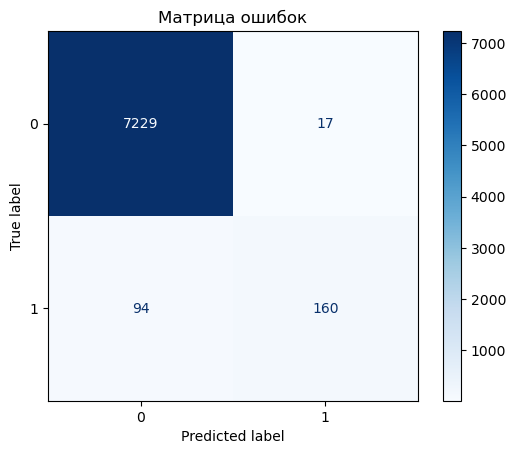

In [112]:
best_model1, cv_results_1 = models(param_grid1, pipe_final1)

'Лучший кросс‑валидированный скор: -0.739'
'Метрики на тренировочной выборке:'
'F1 score: 0.7425'
'F2 score: 0.6706'
'Accuracy: 0.9852'
'Recall: 0.6299'
'Precision: 0.9040'
'ROC AUC: 0.8138'
'MCC: 0.748'

In [114]:
tree_model = best_model1.named_steps['models']
feature_names1 = best_model1.named_steps['preprocessor'].get_feature_names_out()

In [115]:
plt.figure(figsize=(150, 100)) 

# Отрисовка дерева
plot_tree(
    tree_model, 
    feature_names=feature_names1, 
    class_names=['0', '1'], 
    filled=True, 
    rounded=True,
    # Увеличиваем шрифт до экстремального уровня
    fontsize=100, 
    precision=2,
    # Показываем все метки, это заставит прямоугольники расшириться
    label='all',
    impurity=True,
    node_ids=False 
)

# Заголовок тоже делаем соразмерным
plt.title("Дерево решений (DecisionTree)", fontsize=200, pad=150)

# Максимально растягиваем содержимое на все 150 дюймов
plt.tight_layout()


### Обучим KNeighborsClassifier

In [117]:
param_grid2 = [    
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': [2, 12, 24, 35],
        'models__weights': ['uniform', 'distance'],
        'models__metric': ['euclidean', 'manhattan', 'minkowski'],
        'models__leaf_size': [10, 26, 42, 58],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']   
    }
]

C:\Anaconda\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning:

invalid value encountered in cast



'Лучшая модель и её параметры:\n\n'

Pipeline(steps=[('feature_gen', FeatureGenerator()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Type', 'AT_cat', 'HDF_cat',
                                                   'OSF_cat', 'PWF_cat']),
                                                 ('num', RobustScaler(),
                                                  ['Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Tool wear [min]',
                                                   'HDF_temp'])])),
                ('models',
                 KNeighborsClassifier(leaf_size=42, metric='manhattan',
                                      n_neighbors=12, weights='distance'))])

'Лучший кросс‑валидированный скор: -0.731'

'Метрики на тренировочной выборке:'

'F1 score: 0.7329'

'F2 score: 0.6540'

'Accuracy: 0.9849'

'Recall: 0.6102'

'Precision: 0.9172'

'ROC AUC: 0.8042'

'MCC: 0.741'

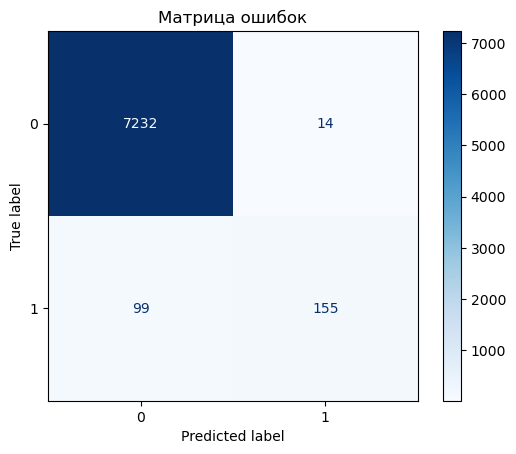

In [118]:
best_model2, cv_results_2 = models(param_grid2, pipe_final1)

Модель KNeighborsClassifier уступает предыдущей модели по качеству метрик.

### Обучение модели LogisticRegression

In [121]:
param_grid3 = [

    # Группа 2: solver='saga' → поддерживает 'l1', 'l2', 'elasticnet'
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__penalty': ['l1', 'l2', 'elasticnet'],
        'models__C': [80, 100, 120, 160],
        'models__l1_ratio': [0.1, 0.5, 0.9],  # только для elasticnet
        'models__solver': ['saga'],
        'models__max_iter': [800],
        'models__class_weight': ['balanced', None],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]

'Лучшая модель и её параметры:\n\n'

Pipeline(steps=[('feature_gen', FeatureGenerator()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Type', 'AT_cat', 'HDF_cat',
                                                   'OSF_cat', 'PWF_cat']),
                                                 ('num', MinMaxScaler(),
                                                  ['Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Tool wear [min]',
                                                   'HDF_temp'])])),
                ('models',
                 LogisticRegression(C=80, l1_ratio=0.1, max_iter=800,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])

'Лучший кросс‑валидированный скор: -0.689'

'Метрики на тренировочной выборке:'

'F1 score: 0.6892'

'F2 score: 0.6343'

'Accuracy: 0.9816'

'Recall: 0.6024'

'Precision: 0.8053'

'ROC AUC: 0.7986'

'MCC: 0.688'

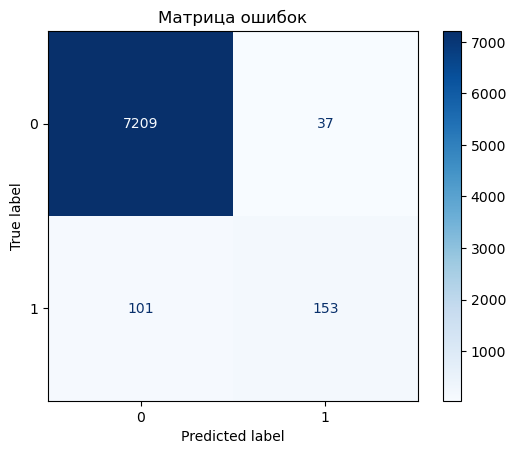

In [122]:
best_model3, cv_results_3 = models(param_grid3, pipe_final1)

In [123]:
model = best_model3.named_steps['models']
preprocessor = best_model3.named_steps['preprocessor']

# 2. Получаем имена признаков после трансформации (OHE и т.д.)
feature_names = preprocessor.get_feature_names_out()

# 3. Создаем DataFrame для удобного отображения
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_[0]
})

# 4. Сортируем по силе влияния (по абсолютному значению)
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False).drop(columns='abs_coefficient')

# Выводим коэффициенты и интерцепт (смещение)
print(f"Intercept (смещение): {model.intercept_[0]:.4f}")
display(coef_df)

Intercept (смещение): -0.1720


,feature,coefficient
4,ohe__OSF_cat_1,5.939116
3,ohe__HDF_cat_1,-5.831481
7,num__Rotational speed [rpm],4.324174
6,num__Process temperature [K],-0.969828
5,ohe__PWF_cat_1,0.646874
0,ohe__Type_L,0.639353
8,num__Tool wear [min],0.635216
2,ohe__AT_cat_1,0.612382
9,num__HDF_temp,-0.433932
1,ohe__Type_M,0.312438


Модель LogisticRegression уступает двум предыдущим моделям.

### Обучение модели LGBMClassifier

In [126]:
param_grid5 = [    
    {   'models': [LGBMClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [125, 250, 370],
        'models__max_depth': range(-1, 16),
        'models__learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4],
        'models__num_leaves': range(15, 120),
        'models__min_child_samples': range(1, 15),
        'models__min_split_gain': [0.0, 0.1],
        'models__class_weight': ['balanced', None],
        'models__verbose': [-1],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]

C:\Anaconda\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning:

invalid value encountered in cast



'Лучшая модель и её параметры:\n\n'

Pipeline(steps=[('feature_gen', FeatureGenerator()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Type', 'AT_cat', 'HDF_cat',
                                                   'OSF_cat', 'PWF_cat']),
                                                 ('num', StandardScaler(),
                                                  ['Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Tool wear [min]',
                                                   'HDF_temp'])])),
                ('models',
                 LGBMClassifier(learning_rate=0.2, max_depth=2,
                                min_child_samples=1, n_estimators=125,
                                num_leaves=118, random_state=42, verbose=-1))])

'Лучший кросс‑валидированный скор: -0.754'

'Метрики на тренировочной выборке:'

'F1 score: 0.7569'

'F2 score: 0.6886'

'Accuracy: 0.9859'

'Recall: 0.6496'

'Precision: 0.9066'

'ROC AUC: 0.8236'

'MCC: 0.761'

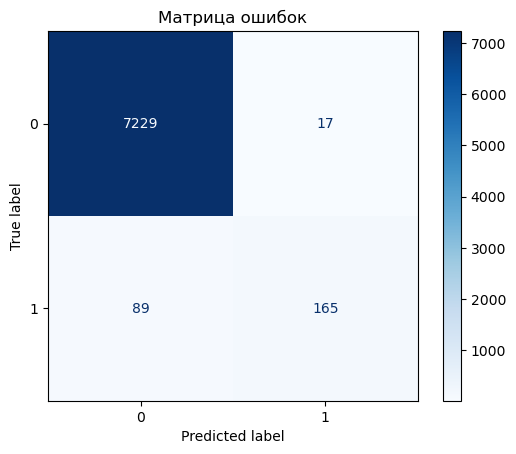

In [127]:
best_model5, cv_results_5 = models(param_grid5, pipe_final1)

LGBMClassifier вырывается вперел по качеству метрик.

### Обучение модели RandomForestClassifier

In [130]:
param_grid7 =  {    
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [100, 125, 150],
        'models__max_depth': [20, 30, 40],
        'models__min_samples_split': range(2, 7),
        'models__min_samples_leaf': range(2, 5),
        'models__class_weight': ['balanced', None],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }

'Лучшая модель и её параметры:\n\n'

Pipeline(steps=[('feature_gen', FeatureGenerator()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Type', 'AT_cat', 'HDF_cat',
                                                   'OSF_cat', 'PWF_cat']),
                                                 ('num', MinMaxScaler(),
                                                  ['Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Tool wear [min]',
                                                   'HDF_temp'])])),
                ('models',
                 RandomForestClassifier(max_depth=30, min_samples_leaf=2,
                                        min_samples_split=6,
                                        random_state=42))])

'Лучший кросс‑валидированный скор: -0.747'

'Метрики на тренировочной выборке:'

'F1 score: 0.7517'

'F2 score: 0.6790'

'Accuracy: 0.9857'

'Recall: 0.6378'

'Precision: 0.9153'

'ROC AUC: 0.8179'

'MCC: 0.758'

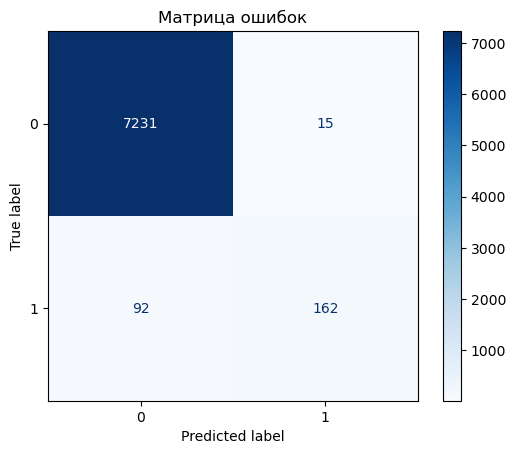

In [131]:
best_model7, cv_results_7 = models(param_grid7, pipe_final1)

Модель RandomForestClassifier уступает модели LGBMClassifier.

### Лучшая модель

LGBMClassifier
Parameters
boosting_type	'gbdt'
num_leaves	118
max_depth	2
learning_rate	0.2
n_estimators	125
subsample_for_bin	200000
objective	None
class_weight	None
min_split_gain	0.0
min_child_weight	0.001
min_child_samples	1
subsample	1.0
subsample_freq	0
colsample_bytree	1.0
reg_alpha	0.0
reg_lambda	0.0
random_state	42
n_jobs	None
importance_type	'split'
verbose	-1

'Метрики на тренировочной выборке:'\
'F1 score: 0.7569'\
'F2 score: 0.6886'\
'Accuracy: 0.9859'\
'Recall: 0.6496'\
'Precision: 0.9066'\
'ROC AUC: 0.8236'\
'MCC: 0.761'

In [135]:
def to_matrix(best_model1, y_train25, y_train_cv_pred):
    cm5 = confusion_matrix(y_train25, y_train_cv_pred)

    disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=best_model1.classes_)
    disp5.plot(cmap=plt.cm.Blues)
    plt.title('Матрица ошибок')
    plt.show()

'Метрики по результатам тестовой выборки:'

'F1 score: 0.7974'

'F2 score: 0.7475'

'Accuracy: 0.9876'

'Recall: 0.7176'

'Precision: 0.8971'

'ROC AUC: 0.8574'

'MCC: 0.796'

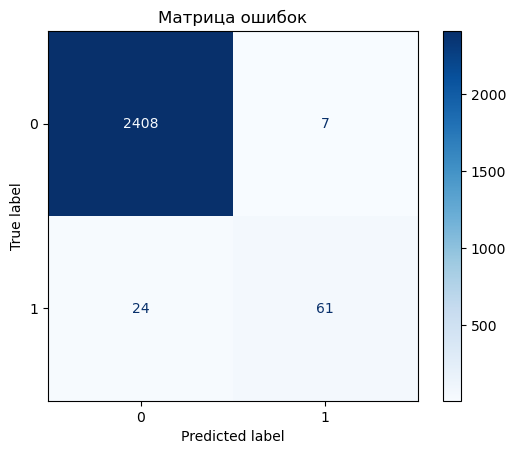

In [136]:
y_pred5 = best_model5.predict(X_test25)
metrics(y_test25, y_pred5)
to_matrix(best_model5, y_test25, y_pred5)

'Метрики по результатам тестовой выборки:'\
'F1 score: 0.7974'\
'F2 score: 0.7475'\
'Accuracy: 0.9876'\
'Recall: 0.7176'\
'Precision: 0.8971'\
'ROC AUC: 0.8574'\
'MCC: 0.796'

## Важность признаков модели

### SHAP

In [140]:
def shapvalue(randomized_search, X_train, X_test):
    model = randomized_search.named_steps['models']  # CatBoostClassifier
    preprocessing_pipeline = Pipeline([
        ('feature_gen', randomized_search.named_steps['feature_gen']),
        ('preprocessor', randomized_search.named_steps['preprocessor'])
    ])
    
    
    # Преобразуем данные
    X_train_processed = preprocessing_pipeline.transform(X_train)
    X_test_processed = preprocessing_pipeline.transform(X_test)
    
    
    # Создаём Explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_processed)
    
    
    # Имена признаков
    feature_names = preprocessor.get_feature_names_out()
    
    
    return shap_values, feature_names, X_test_processed, explainer

In [141]:
shap_values, feature_names, X_test_processed, explainer = shapvalue(best_model5, X_train25, X_test25)

if isinstance(shap_values, list):
    shap_values = shap_values[0]  


explanation = shap.Explanation(
    values=shap_values,
    feature_names=feature_names,
    data=X_test_processed  
)

C:\Anaconda\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



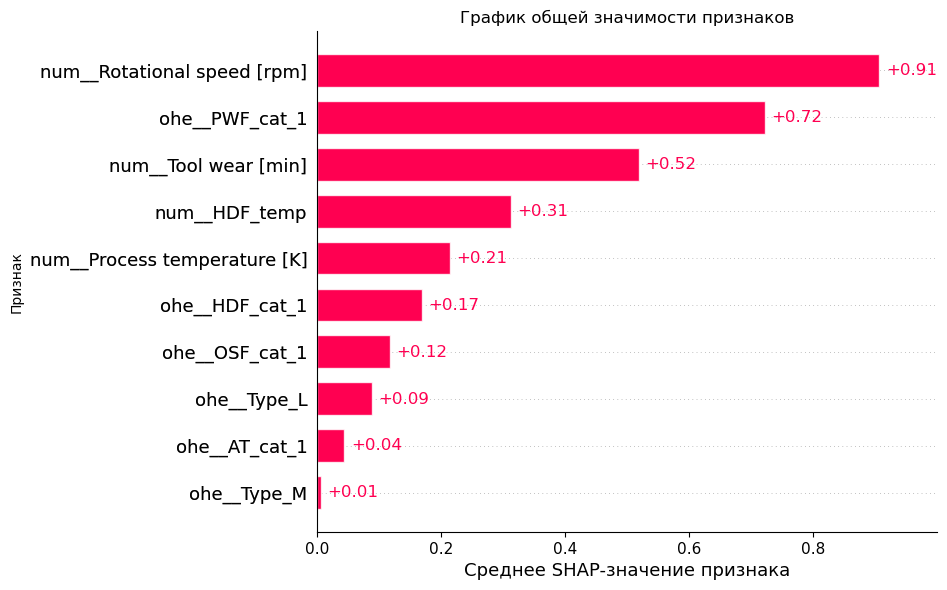

In [142]:
shap.plots.bar(explanation, max_display=17, show=False)
plt.xlabel("Среднее SHAP-значение признака")
plt.ylabel("Признак")
plt.title("График общей значимости признаков")
plt.show()

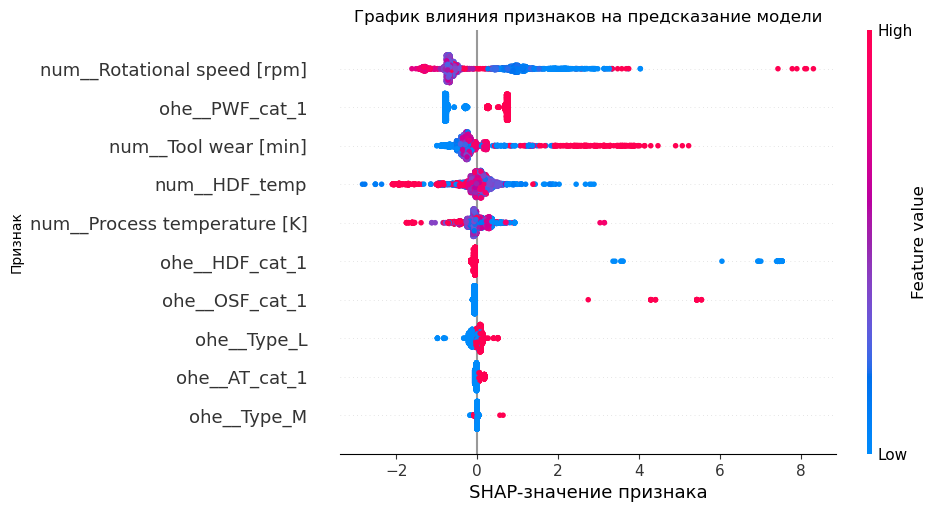

In [143]:
shap.plots.beeswarm(explanation, max_display=16, show=False)
plt.xlabel("SHAP-значение признака")
plt.ylabel("Признак")
plt.title("График влияния признаков на предсказание модели")
plt.show()

Важность признаков (топ 5):\
1 Rotation speed (0.91) - чем она меньше, тем выше риск поломки.\
2 PWF_cat (0.72) - если равно 1, вероятность поломки выше.\
3 Tool Wear (0.52) - чем фактор выше, тем выше риск поломки.\
4 HDF_temp (0.31) - чем фактор ниже, тем выше риск поломки.\
5 Process Tempurature (0.21) - чем фактор ниже, тем выше риск поломки.

Несколько частных случаев для демонстрации:

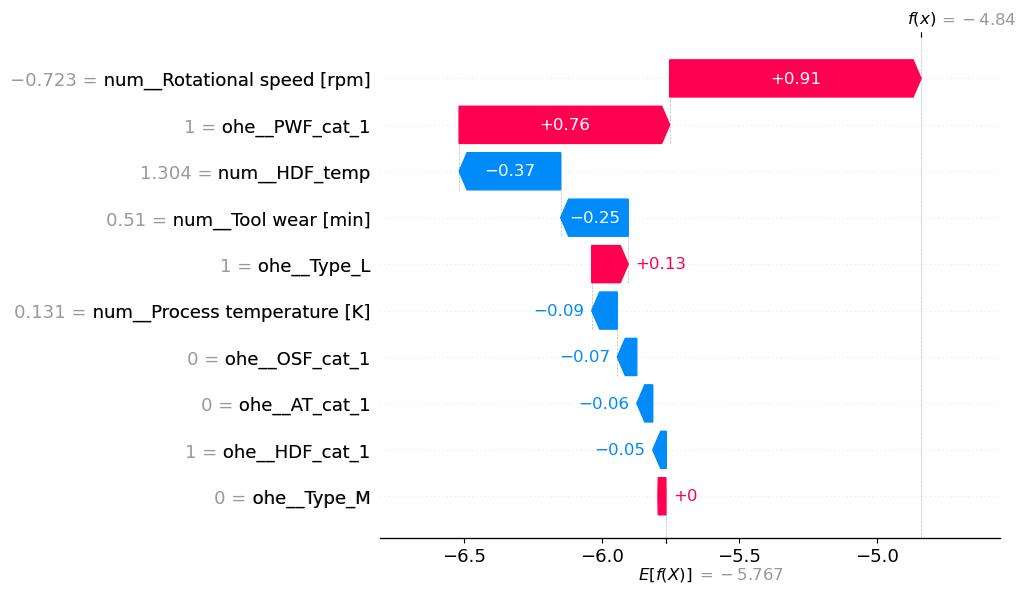

In [146]:
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] # Берем для класса 1

# 2. Убеждаемся, что shap_vals — это массив для нужного класса
# SHAP для LightGBM возвращает список [array_class_0, array_class_1]
if isinstance(shap_values, list):
    current_shap_vals = shap_values[1]
else:
    current_shap_vals = shap_values

# 3. Выбираем объект для объяснения (например, первый в выборке — индекс 0)
sample_idx = 0

# 4. Создаем объект Explanation для конкретной строки
exp_single = shap.Explanation(
    values=current_shap_vals[sample_idx], 
    base_values=expected_value,
    data=X_test_processed[sample_idx],
    feature_names=feature_names
)

# 5. Строим график
shap.plots.waterfall(exp_single)

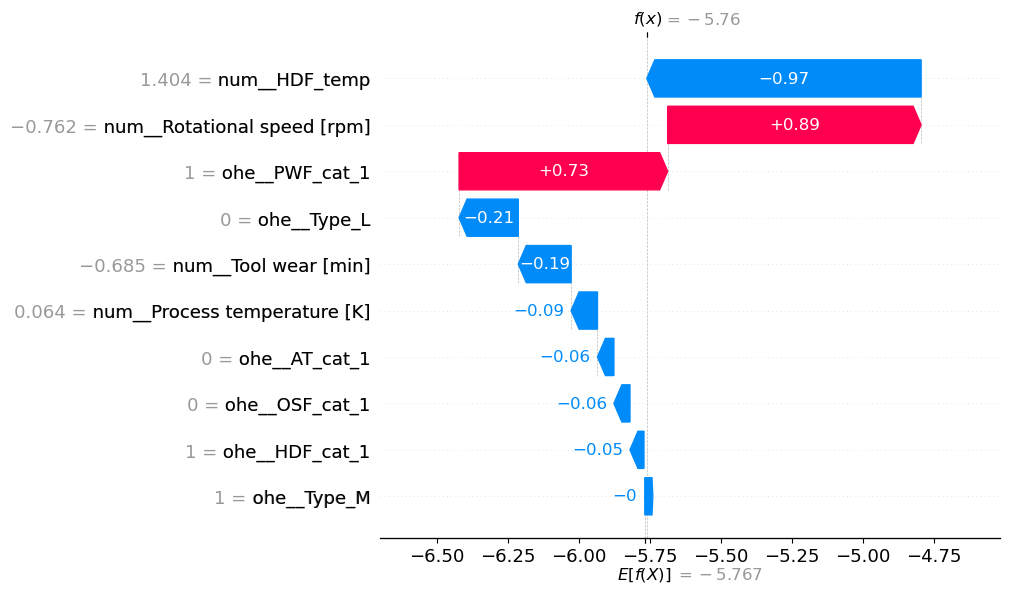

In [147]:
sample_idx = 16

# 4. Создаем объект Explanation для конкретной строки
exp_single = shap.Explanation(
    values=current_shap_vals[sample_idx], 
    base_values=expected_value,
    data=X_test_processed[sample_idx],
    feature_names=feature_names
)

# 5. Строим график
shap.plots.waterfall(exp_single)

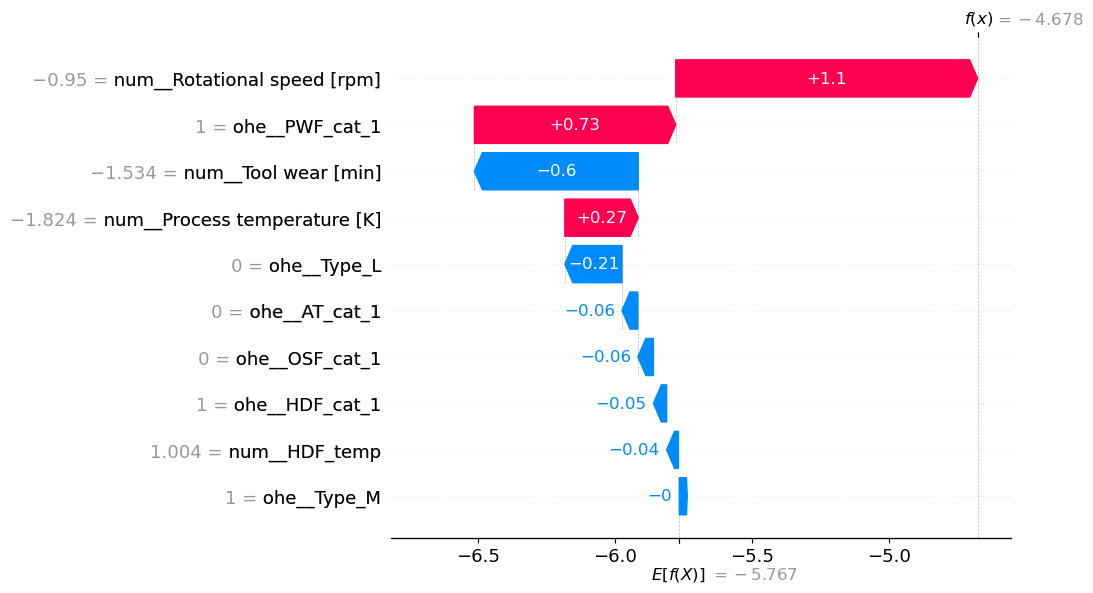

In [148]:
sample_idx = 11

# 4. Создаем объект Explanation для конкретной строки
exp_single = shap.Explanation(
    values=current_shap_vals[sample_idx], 
    base_values=expected_value,
    data=X_test_processed[sample_idx],
    feature_names=feature_names
)

# 5. Строим график
shap.plots.waterfall(exp_single)

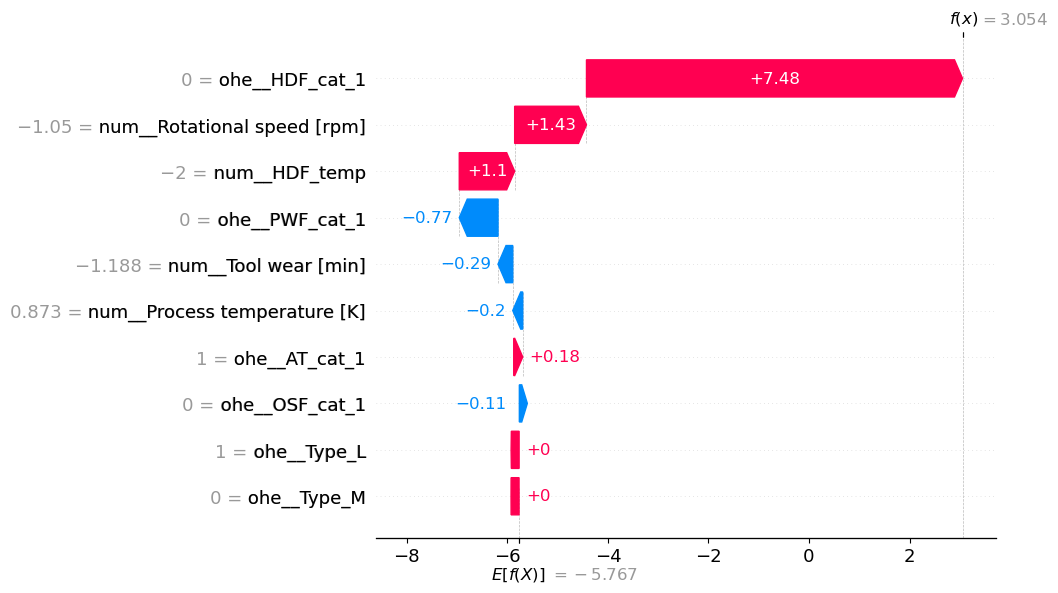

In [149]:
sample_idx = 79

# 4. Создаем объект Explanation для конкретной строки
exp_single = shap.Explanation(
    values=current_shap_vals[sample_idx], 
    base_values=expected_value,
    data=X_test_processed[sample_idx],
    feature_names=feature_names
)

# 5. Строим график
shap.plots.waterfall(exp_single)

## Выводы:

1 Проведен исследовательский анализ данных.

2 Созданы новые признаки:\
- 'HDF_temp' - разница признаков 'Process temperature [K]' и 'Air temperature [K]'\
- 'PWF_n' - произведение признаков 'Torque [Nm]' и 'Rotational speed [rpm]'\
- 'OSF_n' - произведение признаков 'Torque [Nm]' и 'Tool wear [min]'

3 Обнаружены следующие зависимости в данных нормального состояния (0) и отказа (1):\ 
3.1 TWF - Tool Wear Failure (Отказ из-за износа инструмента):\ 
- Tool wear [min] -  0: Q25-Q75: 53-162, 1: Q25-Q75: 198-26

3.2 HDF - Heat Dissipation Failure (Отказ теплоотвода):\
- Air temperature [K] - 0: Q25-Q75: 298.3-301.5, 1: Q25-Q75: 302.1-303.075\
- Rotational speed [rpm] - 0: Q25-Q75: 1426-1614, 1: Q25-Q75: 1259-1379\
- Torque [Nm] - 0: Q25-Q75: 33.1-46.6, 1: Q25-Q75: 48.2-57.1\
- HDF_temp: Q25-Q75: 9.3-11, 1: Q25-Q75: 7.6-8.6

3.4 PWF - Power Failure (Отказ питания):\
- Rotational speed [rpm] -  0: Q25-Q75: 1424-1611, 1: Q25-Q75: 1312-2563.75\
- Tool wear [min] - 0: Q25-Q75: 52-161, 1: Q25-Q75: 172-238\
- PWF_n - 0: Q25-Q75: 885.6-1112.2, 1: Q25-Q75: 546.8-1494

3.5 OSF - Overstrain Failure (Отказ из-за перегрузки):\
- Tool wear [min] - 0: Q25-Q75: 52-161, 1: Q25-Q75: 172-238\
- Torque [Nm] - 0: Q25-Q75: 33.1-46.6, 1: Q25-Q75: 46.3-70.5\
- OSF_n - 0: Q25-Q75: 1846.87-6232.8, 1: Q25-Q75: 110032.8-16479

4 Сгенерированы новые признаки:\
4.1 TW_cat (признак Tool wear [min] больше или меньше 198)\
4.2 AT_cat (признак Air temperature [K] больше или меньше 301.6)\
4.3 HDF_cat - комбинация признаков HDF_temp (больше или меньше 8.7) и 'Rotational speed [rpm]' (больше или меньше < 1380)\
4.4 PWF_cat - (признак PWF_n > 885.5 и < 1112.3)

5 Проведен корреляционный анализ данных - признаки с мультиколлинеарностью удалены.

6 Обучено несколько моделей с перебором гипрепраметров. Целевая метрика - f1 (т.к. мы хотим посмотреть на баланс метрик recall и precision), целевой признак - Machine failure. Лучшей моделью является LGBMClassifier: Parameters boosting_type 'gbdt' num_leaves 118 max_depth 2 learning_rate 0.2 n_estimators 125 subsample_for_bin 200000 objective None class_weight None min_split_gain 0.0 min_child_weight 0.001 min_child_samples 1 subsample 1.0 subsample_freq 0 colsample_bytree 1.0 reg_alpha 0.0 reg_lambda 0.0 random_state 42 n_jobs None importance_type 'split' verbose -1

'Метрики по результатам тестовой выборки:'\
'F1 score: 0.7974'\
'F2 score: 0.7475'\
'Accuracy: 0.9876'\
'Recall: 0.7176'\
'Precision: 0.8971'\
'ROC AUC: 0.8574'\
'MCC: 0.796'

7 Оценена важность признаков:\
1 Rotation speed (0.91) - чем она меньше, тем выше риск поломки.\
2 PWF_cat (0.72) - если равно 1, вероятность поломки выше.\
3 Tool Wear (0.52) - чем фактор выше, тем выше риск поломки.\
4 HDF_temp (0.31) - чем фактор ниже, тем выше риск поломки.\
5 Process Tempurature (0.21) - чем фактор ниже, тем выше риск поломки.

## Сохранение лучшей модели

In [153]:
"""
try:
    joblib.dump(best_model5, 'MF_model5.pkl');
    display("Модель сохранена!")
except:
    display("Ошибка сохранения модели!")
    traceback.print_exc()
"""

'\ntry:\n    joblib.dump(best_model5, \'MF_model5.pkl\');\n    display("Модель сохранена!")\nexcept:\n    display("Ошибка сохранения модели!")\n    traceback.print_exc()\n'

In [154]:
#X_test25.to_csv('MF_test.csv', index=False)